In [56]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


import matplotlib.pyplot as plt


/kaggle/input/datasets/shauryasrivastava01/imdb-top-250-movies-of-all-time-19212025/movies.csv


In [57]:
df = pd.read_csv('/kaggle/input/datasets/shauryasrivastava01/imdb-top-250-movies-of-all-time-19212025/movies.csv')
df.head(5)

,title,year,rating,votes,runtime,certificate,genre,gross_total
0,The Shawshank Redemption,1994,9.3,"3,168,010",142,R,Drama,$29.33M
1,The Godfather,1972,9.2,"2,212,884",175,R,"Crime, Drama",$250.93M
2,The Dark Knight,2008,9.1,"3,145,646",152,PG-13,"Action, Crime, Drama",$1008.48M
3,The Godfather Part II,1974,9.0,"1,486,878",202,R,"Crime, Drama",$48.20M
4,12 Angry Men,1957,9.0,"977,359",96,Unrated,"Crime, Drama",$0.01M


In [58]:
df.dtypes

title           object
year             int64
rating         float64
votes           object
runtime          int64
certificate     object
genre           object
gross_total     object
dtype: object

In [59]:
df[['title','year','rating','votes','runtime','certificate','genre','gross_total']].isnull().sum()

title          0
year           0
rating         0
votes          0
runtime        0
certificate    0
genre          0
gross_total    4
dtype: int64

In [60]:
df['gross_total'] = df['gross_total'].fillna('gross_total')

In [61]:
df['gross_total'].isnull().sum()

np.int64(0)

#  Fix gross: remove $ and M, convert to number

In [62]:
# Fix votes: remove commas, convert to number
df['votes'] = df['votes'].astype(str).str.replace(',', '').astype(float)

# Fix gross: remove $ and M, convert to number
df['gross_millions'] = (
    df['gross_total']
    .astype(str)
    .str.replace('$','',regex = False)
    .str.replace('M','',regex=False)
    
)
df['gross_millions'] = pd.to_numeric(df['gross_millions'], errors = 'coerce')

df.head()

,title,year,rating,votes,runtime,certificate,genre,gross_total,gross_millions
0,The Shawshank Redemption,1994,9.3,3168010.0,142,R,Drama,$29.33M,29.33
1,The Godfather,1972,9.2,2212884.0,175,R,"Crime, Drama",$250.93M,250.93
2,The Dark Knight,2008,9.1,3145646.0,152,PG-13,"Action, Crime, Drama",$1008.48M,1008.48
3,The Godfather Part II,1974,9.0,1486878.0,202,R,"Crime, Drama",$48.20M,48.20
4,12 Angry Men,1957,9.0,977359.0,96,Unrated,"Crime, Drama",$0.01M,0.01


In [63]:
print('shape :',df.shape)

shape : (250, 9)


In [64]:
print(df.isnull().sum())

title             0
year              0
rating            0
votes             0
runtime           0
certificate       0
genre             0
gross_total       0
gross_millions    4
dtype: int64


In [65]:
df['gross_millions'] = df['gross_millions'].fillna('gross_millions')

In [66]:
print("\n Basic Stats:")
df[['rating','votes','runtime','year']].describe()


 Basic Stats:


,rating,votes,runtime,year
count,250.000000,2.500000e+02,250.000000,250.000000
mean,8.310400,7.553460e+05,131.932000,1988.972000
std,0.231747,6.219561e+05,36.547589,25.393197
min,8.000000,2.781100e+04,45.000000,1921.000000
25%,8.100000,2.413208e+05,108.250000,1973.000000
50%,8.200000,6.095160e+05,127.500000,1995.500000
75%,8.400000,1.142126e+06,147.750000,2009.000000
max,9.300000,3.168010e+06,374.000000,2025.000000


In [67]:
# 1. Decade — which 10-year period the movie came from
#    Example: 1994 → 1990s

df['decade'] = (df['year'] // 10*10).astype(str) + 's'
# 2. Cinema Era — broad period of film history
def get_era(year):
    if year < 1950 : return 'Classic Era'
    elif year < 1970 : return 'Golden Age'
    elif year < 1990 : return 'New Hollywood'
    elif year < 2010 : return 'Blockbuster Era'
    else: return 'Streaming Era'

df['era'] = df['year'].apply(get_era)

# 3. Primary genre — just the first genre listed
#    Example: 'Action, Crime, Drama' → 'Action'
df['primary_genre'] = df['genre'].str.split(',').str[0].str.strip()

# 4. Runtime category — label based on movie length
def get_runtime_cat (mins):
    if mins < 90 : return 'Short'
    elif mins < 120: return 'Standard'
    elif mins < 150: return 'Long'
    elif mins < 180 : return 'Very Long'
    else : return 'Epic'

df['runtime_cat'] = df['runtime'].apply(get_runtime_cat)
df.head()

,title,year,rating,votes,runtime,certificate,genre,gross_total,gross_millions,decade,era,primary_genre,runtime_cat
0,The Shawshank Redemption,1994,9.3,3168010.0,142,R,Drama,$29.33M,29.33,1990s,Blockbuster Era,Drama,Long
1,The Godfather,1972,9.2,2212884.0,175,R,"Crime, Drama",$250.93M,250.93,1970s,New Hollywood,Crime,Very Long
2,The Dark Knight,2008,9.1,3145646.0,152,PG-13,"Action, Crime, Drama",$1008.48M,1008.48,2000s,Blockbuster Era,Action,Very Long
3,The Godfather Part II,1974,9.0,1486878.0,202,R,"Crime, Drama",$48.20M,48.2,1970s,New Hollywood,Crime,Epic
4,12 Angry Men,1957,9.0,977359.0,96,Unrated,"Crime, Drama",$0.01M,0.01,1950s,Golden Age,Crime,Standard


# Visualization

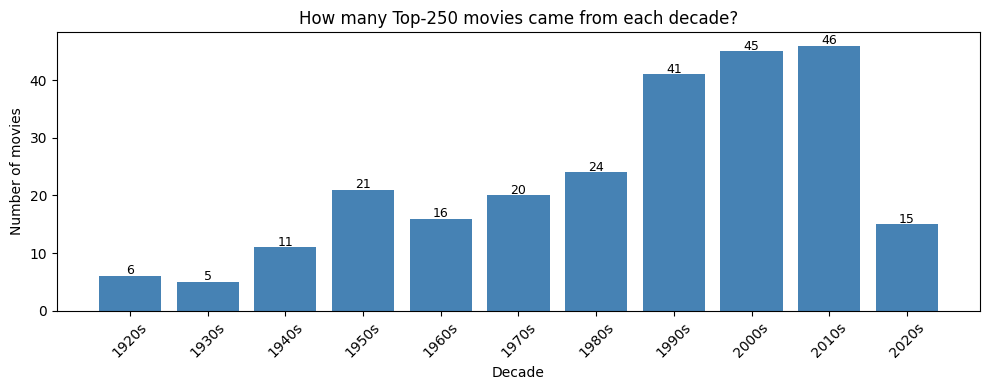

In [68]:
# Chart 1 — How many movies per decade?

decade_counts = df['decade'].value_counts().sort_index()

plt.figure(figsize =(10,4))
plt.bar(decade_counts.index,decade_counts.values,color = 'steelblue')

for i, val in enumerate(decade_counts.values):
    plt.text(i,val + 0.3,str(val),ha='center',fontsize=9)

plt.title('How many Top-250 movies came from each decade?')
plt.xlabel('Decade')
plt.ylabel('Number of movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

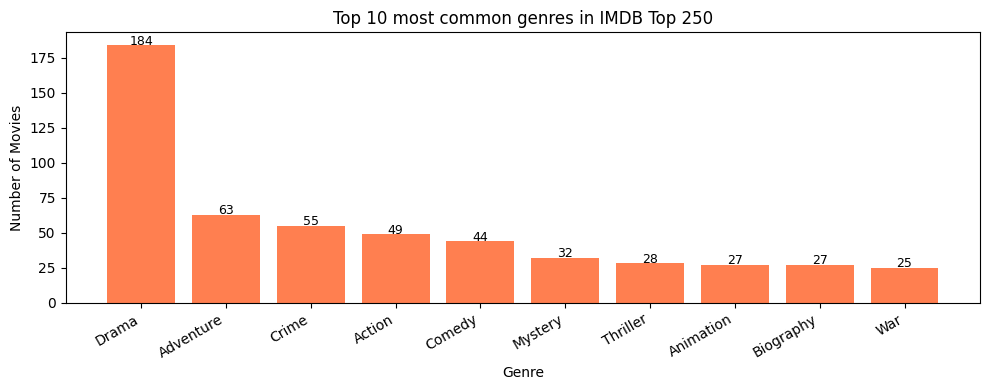

In [71]:
# Chart 2 — Which genres appear most?
# Drama leads by a big margin.

all_genre =df['genre'].str.split(',').explode().str.strip()
genre_counts = all_genre.value_counts().head(10)

plt.figure(figsize=(10,4))
plt.bar(genre_counts.index,genre_counts.values,color='coral')

for i , val in enumerate(genre_counts.values):
    plt.text(i,val + 0.3,str(val),ha='center',fontsize=9)

plt.title('Top 10 most common genres in IMDB Top 250')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xt# Chart 3 — How are ratings spread?icks(rotation=30,ha='right')
plt.tight_layout()
plt.show()

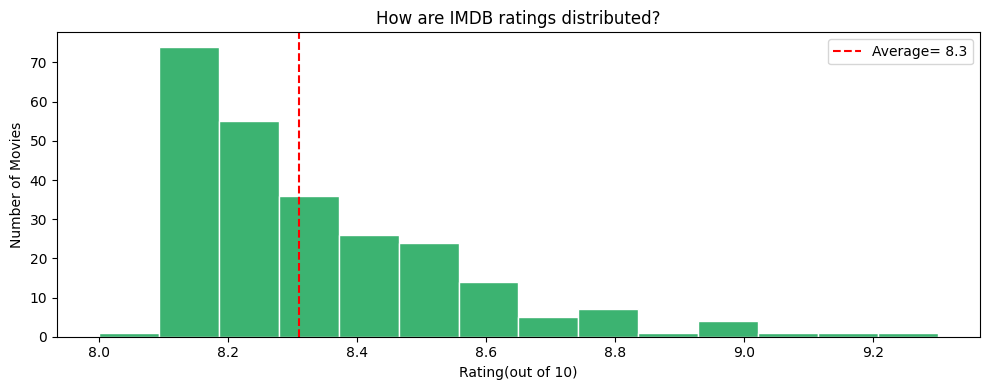

In [72]:
# Chart 3 — How are ratings spread?

plt.figure(figsize=(10,4))
plt.hist(df['rating'],bins=14,color='mediumseagreen',edgecolor='white')

avg = df['rating'].mean()
plt.axvline(avg,color='red',linestyle='--',label=f'Average={avg: .1f}')
plt.legend()
plt.title('How are IMDB ratings distributed?')
plt.xlabel('Rating(out of 10)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

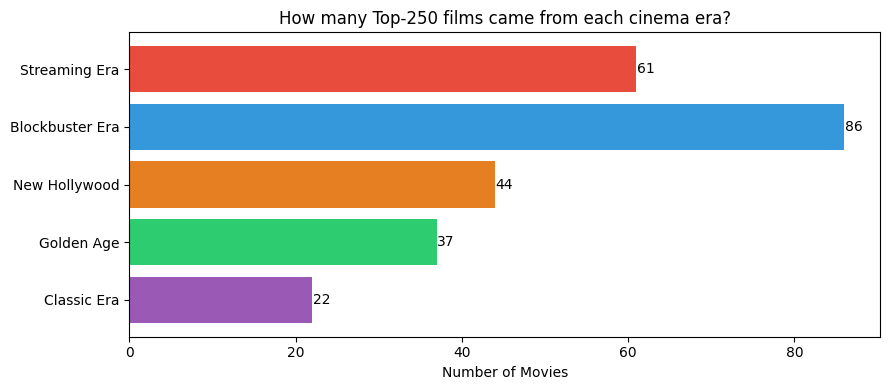

In [74]:
# Chart 4 — Movies by cinema era

era_order = ['Classic Era','Golden Age','New Hollywood','Blockbuster Era','Streaming Era']
era_colors = ['#9b59b6', '#2ecc71', '#e67e22', '#3498db', '#e74c3c']
era_counts = df['era'].value_counts().reindex(era_order)

plt.figure(figsize=(9,4))
bars=plt.barh(era_counts.index,era_counts.values,color= Chart 5 — Runtime categoriesera_colors)

for bar , val in zip(bars,era_counts.values):
    plt.text(val+0.05,bar.get_y()+bar.get_height()/2,str(val),va='center',fontsize=10)

plt.title('How many Top-250 films came from each cinema era?')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.show()

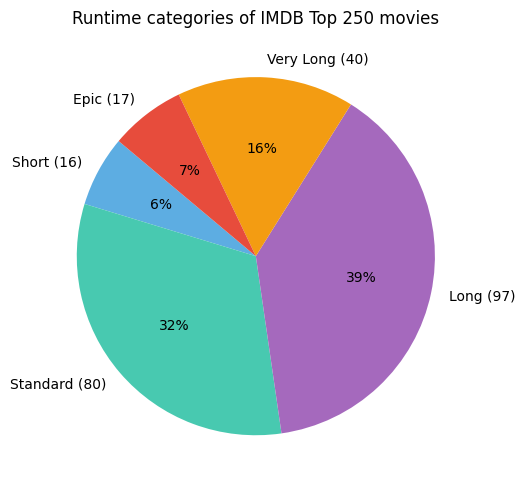

In [76]:
# Chart 5 — Runtime categories

cat_order = ['Short', 'Standard', 'Long', 'Very Long', 'Epic']
cat_colors = ['#5dade2', '#48c9b0', '#a569bd', '#f39c12', '#e74c3c']
runtime_counts = df['runtime_cat'].value_counts().reindex(cat_order)

plt.figure(figsize=(7,5))
plt.pie(
    runtime_counts.values,
    labels=[f'{cat} ({val})' for cat , val in zip(runtime_counts.index,runtime_counts.values)],
    colors=cat_colors,
    autopct='%1.0f%%',
    startangle= 140

)
plt.title('Runtime categories of IMDB Top 250 movies')
plt.tight_layout()
plt.show()
